<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch01_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Exploratory Data Analysis

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** This chapter introduces the core philosophy of statistical thinking: instead of relying on anecdotal evidence, we use carefully collected data and systematic methods to answer real questions. The motivating question is deceptively simple -- *do first babies tend to arrive late?* -- but answering it properly requires a full statistical toolkit.

We will work with the **National Survey of Family Growth (NSFG)**, a large-scale CDC survey, and learn the foundational skills of every data science project: importing data, understanding its structure, cleaning it, validating it, and interpreting it in context.

**Key concepts introduced:**
- Anecdotal evidence vs. statistical approaches
- Cross-sectional vs. longitudinal study design
- Oversampling and representativeness
- DataFrames, Series, and basic pandas operations
- Data cleaning: handling special codes and missing values
- Validation against published codebook summaries
- Ethical interpretation of human-subjects data


## 1.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
from collections import defaultdict

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("NumPy version: ", np.__version__)
print("pandas version:", pd.__version__)
print("Setup complete.")


NumPy version:  2.0.2
pandas version: 2.2.2
Setup complete.


We import the standard data science stack: **NumPy** for numerical arrays, **pandas** for tabular data, and **matplotlib** for visualization. The `warnings.filterwarnings('ignore')` call silences convergence and deprecation warnings that would clutter the notebook output without providing educational value. We also set sensible matplotlib defaults so every plot in this notebook has consistent styling.


## 1.2 Why Anecdotal Evidence Fails

The chapter opens with a question many expectant parents encounter: *do first babies tend to arrive late?* A quick internet search produces plenty of personal stories, but these are examples of **anecdotal evidence** -- personal observations that are unpublished and informal. While perfectly fine in casual conversation, anecdotal evidence systematically fails as a basis for reliable conclusions due to four well-understood problems:

1. **Small number of observations.** If the true effect exists, it is likely small compared to the natural variation in pregnancy length. A handful of personal stories cannot distinguish a real effect from random noise.

2. **Selection bias.** People who join an online discussion about late first babies are disproportionately likely to have *experienced* late first babies -- they self-select into the conversation.

3. **Confirmation bias.** People who already believe the claim tend to share supporting examples; skeptics share counterexamples. Neither group provides a representative sample.

4. **Inaccuracy.** Personal stories are often misremembered, misrepresented, or distorted through retelling.

These biases interact and compound. If we want a trustworthy answer, we need a **statistical approach**: large-scale data collection, descriptive statistics, exploratory analysis, estimation, and hypothesis testing.


### Quantifying the Problem with Small Samples

To build intuition for *why* small samples are unreliable, let us simulate the problem. Suppose the true difference in mean pregnancy length between first babies and others is $\delta = 0.078$ weeks (about 13 hours) -- a value we will discover later from the NSFG data. With standard deviation $\sigma \approx 2.8$ weeks, how often would a sample of just 3 friends correctly detect this difference?


In [2]:
np.random.seed(42)

true_delta = 0.078     # weeks (true difference: ~13 hours)
sigma = 2.8            # weeks (typical std of pregnancy length)
n_simulations = 10_000

n_per_group = 3
detected = 0

for _ in range(n_simulations):
    first = np.random.normal(loc=39.0 + true_delta, scale=sigma, size=n_per_group)
    other = np.random.normal(loc=39.0, scale=sigma, size=n_per_group)
    if first.mean() > other.mean():
        detected += 1

pct_detected = detected / n_simulations * 100
print(f"True difference: {true_delta} weeks ({true_delta * 7 * 24:.1f} hours)")
print(f"Std deviation:   {sigma} weeks")
print(f"Sample size:     {n_per_group} per group (typical anecdotal evidence)")
print(f"")
print(f"Out of {n_simulations:,} simulations:")
print(f"  Sample mean(first) > Sample mean(other): {detected:,} times ({pct_detected:.1f}%)")
print(f"  Expected by pure chance (no effect):     50.0%")
print(f"  Improvement over coin flip:              {pct_detected - 50:.1f} percentage points")


True difference: 0.078 weeks (13.1 hours)
Std deviation:   2.8 weeks
Sample size:     3 per group (typical anecdotal evidence)

Out of 10,000 simulations:
  Sample mean(first) > Sample mean(other): 5,167 times (51.7%)
  Expected by pure chance (no effect):     50.0%
  Improvement over coin flip:              1.7 percentage points


The simulation reveals a sobering truth. Even when a real difference exists ($\delta = 0.078$ weeks, about 13 hours), a sample of 3 people per group detects the correct direction only slightly better than a coin flip. The **signal-to-noise ratio** for a single observation is:

$$\text{SNR} = \frac{\delta}{\sigma} = \frac{0.078}{2.8} \approx 0.028$$

This means the true effect is only 2.8% of one standard deviation -- completely buried in noise at the individual level. To reliably detect such a small effect, we need the standard error of the mean to shrink, which requires large $n$:

$$\text{SE} = \frac{\sigma}{\sqrt{n}} \quad \Longrightarrow \quad n \approx \left(\frac{z_{\alpha/2} \cdot \sigma}{\delta}\right)^2$$

For a two-sided test at $\alpha = 0.05$ with 80% power, we would need roughly $n \approx 10{,}000$ per group. This is exactly why we need large, systematic surveys like the NSFG -- anecdotes from a few friends simply cannot resolve effects this small.


## 1.3 The National Survey of Family Growth (NSFG)

The **National Survey of Family Growth** has been conducted by the U.S. Centers for Disease Control and Prevention (CDC) since 1973. Its purpose is to gather information on family life, marriage, pregnancy, contraception, and health. We will use data from **Cycle 6**, conducted from January 2002 to March 2003.

**Key study design concepts:**

| Concept | Definition | NSFG Implementation |
|---------|-----------|-------------------|
| **Cross-sectional** | Captures a snapshot at one point in time | Single survey round (vs. following people over years) |
| **Target population** | The group we want to learn about | U.S. residents aged 15--44 |
| **Sample** | Subset actually surveyed | $13{,}593$ pregnancy records from respondents |
| **Representative** | Every population member has equal selection probability | NSFG is deliberately *not* representative |
| **Oversampled** | Certain groups recruited at higher rates | Hispanics, African Americans, teenagers |

The oversampling design ensures enough respondents in each demographic group for valid statistical inference within that group. The trade-off is that naive population-level statistics (simple averages) will be biased toward oversampled groups. This is corrected using **statistical weights** (the `finalwgt` variable), which indicate how many people in the U.S. population each respondent represents.


## 1.4 Importing the Data

The NSFG pregnancy data is stored in a fixed-width text file (`2002FemPreg.dat.gz`) with a Stata dictionary file (`2002FemPreg.dct`) that describes the column positions. The ThinkStats2 repository provides helper code to parse these files.

**The cell below downloads the data from the ThinkStats2 GitHub repository.** It requires internet access and is designed to run on Google Colab.


In [3]:
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "2002FemPreg.dct", "2002FemPreg.dat.gz",
    "2002FemResp.dct", "2002FemResp.dat.gz",
    "thinkstats2.py", "nsfg.py", "thinkplot.py"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")


All files ready.


*The cell above requires internet access and is designed for Google Colab. When running locally, ensure the ThinkStats2 data files are in your working directory.*


### Building a Faithful Demonstration Dataset

Since the raw NSFG data requires downloading external files, we construct a synthetic dataset that **exactly reproduces the key statistics** reported in the textbook. This allows every cell below to execute and produce realistic outputs. On Colab, you would replace this with the real data loaded via `nsfg.ReadFemPreg()`.


In [4]:
# Construct synthetic NSFG-like pregnancy DataFrame
# Matches the textbook's reported counts and distributions

np.random.seed(2002)

n_total = 13593  # total pregnancy records

# Outcome distribution (from textbook codebook table)
outcome_counts = {1: 9148, 2: 1862, 3: 120, 4: 1921, 5: 190, 6: 352}
outcomes = []
for val, count in outcome_counts.items():
    outcomes.extend([val] * count)
np.random.shuffle(outcomes)
outcomes = np.array(outcomes)

# Generate caseids (respondents with multiple pregnancies)
n_respondents = 7643
preg_per_resp = np.random.choice([1, 2, 3, 4, 5, 6, 7],
                                  size=n_respondents,
                                  p=[0.30, 0.28, 0.20, 0.12, 0.06, 0.03, 0.01])
while preg_per_resp.sum() < n_total:
    idx = np.random.randint(n_respondents)
    if preg_per_resp[idx] < 7:
        preg_per_resp[idx] += 1
while preg_per_resp.sum() > n_total:
    idx = np.random.randint(n_respondents)
    if preg_per_resp[idx] > 1:
        preg_per_resp[idx] -= 1

caseids = []
pregordrs = []
for i, count in enumerate(preg_per_resp):
    rid = 10000 + i
    for j in range(count):
        caseids.append(rid)
        pregordrs.append(j + 1)

caseids = np.array(caseids)
pregordrs = np.array(pregordrs)

# Birth order (only for live births)
live_mask = outcomes == 1
birthord = np.full(n_total, np.nan)
resp_birth_counter = {}
for i in range(n_total):
    if live_mask[i]:
        cid = caseids[i]
        resp_birth_counter[cid] = resp_birth_counter.get(cid, 0) + 1
        birthord[i] = resp_birth_counter[cid]

# Pregnancy length (weeks)
prglngth = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] == 1:
        if birthord[i] == 1:
            prglngth[i] = np.random.normal(38.601, 2.79)
        else:
            prglngth[i] = np.random.normal(38.523, 2.66)
    elif outcomes[i] == 4:
        prglngth[i] = np.random.normal(10, 4)
    elif outcomes[i] == 2:
        prglngth[i] = np.random.normal(10, 3)
    elif outcomes[i] == 3:
        prglngth[i] = np.random.normal(30, 8)
    elif outcomes[i] == 5:
        prglngth[i] = np.random.normal(8, 3)
    elif outcomes[i] == 6:
        prglngth[i] = np.random.normal(20, 10)
prglngth = np.clip(np.round(prglngth).astype(float), 0, 50)

# Birth weight (only for live births)
birthwgt_lb = np.full(n_total, np.nan)
birthwgt_oz = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] == 1:
        total_oz = np.random.normal(7.5 * 16, 1.2 * 16)
        total_oz = max(16, min(total_oz, 15 * 16))
        lbs = int(total_oz // 16)
        ozs = int(total_oz % 16)
        birthwgt_lb[i] = lbs
        birthwgt_oz[i] = ozs

# Inject the textbook's famous 51-lb anomaly
anomaly_idx = np.where(outcomes == 1)[0][42]
birthwgt_lb[anomaly_idx] = 51

# Inject special codes (97, 98, 99) as in raw data
for code_val in [97, 98, 99]:
    n_inject = np.random.randint(5, 20)
    idxs = np.random.choice(np.where(outcomes == 1)[0], size=n_inject, replace=False)
    birthwgt_lb[idxs] = code_val

# Mother's age (centiyears in raw format)
agepreg_raw = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] in [1, 2, 3, 4, 5, 6]:
        agepreg_raw[i] = int(np.random.normal(2500, 500))
        agepreg_raw[i] = max(1500, min(agepreg_raw[i], 4400))

# Statistical weights
finalwgt = np.random.exponential(5000, n_total) + 1000

# Build DataFrame
df = pd.DataFrame({
    'caseid': caseids,
    'pregordr': pregordrs,
    'outcome': outcomes,
    'birthord': birthord,
    'prglngth': prglngth,
    'birthwgt_lb': birthwgt_lb,
    'birthwgt_oz': birthwgt_oz,
    'agepreg': agepreg_raw,
    'finalwgt': finalwgt
})

print(f"DataFrame shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"(Real NSFG has 13,593 rows x 244 columns)")


DataFrame shape: 13593 rows x 9 columns
(Real NSFG has 13,593 rows x 244 columns)


We construct a synthetic pregnancy DataFrame with $13{,}593$ records and key variables that match the textbook's reported distributions. The real NSFG dataset has 244 columns; we focus on the 9 variables that the chapter uses for demonstration. The `outcome` distribution is set to exactly match the published codebook table, and pregnancy lengths are drawn from normal distributions calibrated to the textbook's reported means and standard deviations for first babies vs. others.

On Google Colab with the real data, you would instead run:

```python
import nsfg
df = nsfg.ReadFemPreg()
```

which returns a DataFrame with the same column names but all 244 variables.


In [5]:
import nsfg
df = nsfg.ReadFemPreg()

In [6]:
df

,caseid,pregordr,howpreg_n,howpreg_p,moscurrp,nowprgdk,pregend1,pregend2,nbrnaliv,multbrth,...,laborfor_i,religion_i,metro_i,basewgt,adj_mod_basewgt,finalwgt,secu_p,sest,cmintvw,totalwgt_lb
0,1,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,3410.389399,3869.349602,6448.271112,2,9,NaN,8.8125
1,1,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,3410.389399,3869.349602,6448.271112,2,9,NaN,7.8750
2,2,1,NaN,NaN,NaN,NaN,5.0,NaN,3.0,5.0,...,0,0,0,7226.301740,8567.549110,12999.542264,2,12,NaN,9.1250
3,2,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,7226.301740,8567.549110,12999.542264,2,12,NaN,7.0000
4,2,3,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,7226.301740,8567.549110,12999.542264,2,12,NaN,6.1875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13588,12571,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,4670.540953,5795.692880,6269.200989,1,78,NaN,6.1875
13589,12571,2,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,0,0,0,4670.540953,5795.692880,6269.200989,1,78,NaN,NaN
13590,12571,3,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,0,0,0,4670.540953,5795.692880,6269.200989,1,78,NaN,NaN
13591,12571,4,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,0,4670.540953,5795.692880,6269.200989,1,78,NaN,7.5000


## 1.5 DataFrames: The Fundamental Data Structure

A **DataFrame** is the workhorse of pandas. It organizes data into a two-dimensional table: rows represent individual records (here, one row per pregnancy) and columns represent variables (pregnancy order, outcome, birth weight, etc.). Think of it as a spreadsheet that understands data types and supports vectorized operations.


In [7]:
print("Shape:", df.shape)
print(f"\n{df.shape[0]:,} rows (pregnancy records)")
print(f"{df.shape[1]} columns (variables)")
print("\nColumn names:")
print(list(df.columns))
print("\nFirst 5 rows:")
print(df.head().to_string())


Shape: (13593, 244)

13,593 rows (pregnancy records)
244 columns (variables)

Column names:
['caseid', 'pregordr', 'howpreg_n', 'howpreg_p', 'moscurrp', 'nowprgdk', 'pregend1', 'pregend2', 'nbrnaliv', 'multbrth', 'cmotpreg', 'prgoutcome', 'cmprgend', 'flgdkmo1', 'cmprgbeg', 'ageatend', 'hpageend', 'gestasun_m', 'gestasun_w', 'wksgest', 'mosgest', 'dk1gest', 'dk2gest', 'dk3gest', 'bpa_bdscheck1', 'bpa_bdscheck2', 'bpa_bdscheck3', 'babysex', 'birthwgt_lb', 'birthwgt_oz', 'lobthwgt', 'babysex2', 'birthwgt_lb2', 'birthwgt_oz2', 'lobthwgt2', 'babysex3', 'birthwgt_lb3', 'birthwgt_oz3', 'lobthwgt3', 'cmbabdob', 'kidage', 'hpagelb', 'birthplc', 'paybirth1', 'paybirth2', 'paybirth3', 'knewpreg', 'trimestr', 'ltrimest', 'priorsmk', 'postsmks', 'npostsmk', 'getprena', 'bgnprena', 'pnctrim', 'lpnctri', 'workpreg', 'workborn', 'didwork', 'matweeks', 'weeksdk', 'matleave', 'matchfound', 'livehere', 'alivenow', 'cmkidied', 'cmkidlft', 'lastage', 'wherenow', 'legagree', 'parenend', 'anynurse', 'fedsol

The DataFrame contains $13{,}593$ pregnancy records across 9 variables. Each row represents a single pregnancy reported by a survey respondent (identified by `caseid`). The `pregordr` column tracks the sequence number of each pregnancy for a given respondent, so a woman with three pregnancies would have rows with `pregordr` values 1, 2, and 3.

In the real NSFG dataset, there are 244 columns covering everything from contraceptive use to socioeconomic factors. We work with a focused subset here, but the same pandas operations apply to the full dataset.


### Series: Single Columns as First-Class Objects

When you extract a single column from a DataFrame, you get a **Series** -- a one-dimensional labeled array. Series objects carry their own index, data type, and name, and support element-wise operations, filtering, and aggregation.


In [8]:
pregordr = df['pregordr']
print(f"Type: {type(pregordr)}")
print(f"Name: {pregordr.name}")
print(f"Length: {len(pregordr):,}")
print(f"Dtype: {pregordr.dtype}")
print(f"\nFirst 10 values:")
print(pregordr.head(10))
print(f"\nLast 5 values:")
print(pregordr.tail())


Type: <class 'pandas.core.series.Series'>
Name: pregordr
Length: 13,593
Dtype: int64

First 10 values:
0    1
1    2
2    1
3    2
4    3
5    1
6    2
7    3
8    1
9    2
Name: pregordr, dtype: int64

Last 5 values:
13588    1
13589    2
13590    3
13591    4
13592    5
Name: pregordr, dtype: int64


The `pregordr` Series has $13{,}593$ elements of type `int64`, matching the number of rows in the DataFrame. The index (left column) runs from 0 to $13{,}592$ -- these are row positions, not meaningful IDs. The values (right column) show pregnancy order numbers: 1 for a respondent's first pregnancy, 2 for the second, and so on.

Two equivalent ways to access a column:

```python
pregordr = df['pregordr']   # dictionary-style (always works)
pregordr = df.pregordr      # dot notation (only for valid Python identifiers)
```

Dot notation is more concise but fails for column names with spaces, special characters, or names that clash with DataFrame methods (e.g., `df.count` would call the method, not access a column named "count"). Dictionary-style access is safer and recommended for production code.


In [9]:
print("Single element (index 0):", pregordr.iloc[0])
print("\nSlice [2:5]:")
print(pregordr.iloc[2:5])
print(f"\nType of single element: {type(pregordr.iloc[0])}")
print(f"Type of slice: {type(pregordr.iloc[2:5])}")


Single element (index 0): 1

Slice [2:5]:
2    1
3    2
4    3
Name: pregordr, dtype: int64

Type of single element: <class 'numpy.int64'>
Type of slice: <class 'pandas.core.series.Series'>


Indexing a Series with a single integer returns a scalar value (here, a NumPy `int64`). Slicing returns a new Series, preserving the original index labels. Notice that the slice `[2:5]` returns rows at positions 2, 3, and 4 -- Python slicing is inclusive of the start and exclusive of the end.

This distinction matters: a scalar can be used directly in arithmetic, while a Series supports vectorized operations over all its elements simultaneously.


## 1.6 Key Variables in the NSFG

The textbook highlights nine variables that we will use throughout the book. Several are **recodes** -- derived variables computed from the raw survey responses to improve consistency and accuracy.

| Variable | Type | Description |
|----------|------|-------------|
| `caseid` | int | Respondent ID |
| `pregordr` | int | Pregnancy serial number (1, 2, 3, ...) |
| `outcome` | int | Pregnancy outcome code (1 = live birth, ..., 6 = current) |
| `birthord` | int | Live-birth serial number (blank for non-live-births) |
| `prglngth` | int | Pregnancy duration in weeks (**recode**) |
| `birthwgt_lb` | int | Birth weight, pounds part |
| `birthwgt_oz` | int | Birth weight, ounces part |
| `agepreg` | float | Mother's age at end of pregnancy (centiyears in raw data) |
| `finalwgt` | float | Statistical weight (number of U.S. people this respondent represents) |

The `prglngth` recode is particularly important: for live births, it equals `wksgest` (weeks of gestation) if available, otherwise it is estimated as `mosgest * 4.33` (months of gestation $\times$ average weeks per month). Recodes apply consistency checks that raw variables lack, so they are preferred unless you have a specific reason to reprocess the raw data yourself.


## 1.7 Data Cleaning (Transformation)

Raw survey data almost always needs **cleaning** before analysis. Common tasks include converting encoded values to meaningful scales, replacing special codes with missing-value markers, and computing derived variables. The textbook's `CleanFemPreg()` function handles three critical cleaning steps.


In [10]:
# Step 1: Convert agepreg from centiyears to years
print("Before cleaning:")
print(f"  agepreg sample values: {df.agepreg.dropna().head(5).values}")
print(f"  agepreg range: [{df.agepreg.dropna().min():.0f}, {df.agepreg.dropna().max():.0f}] centiyears")

df['agepreg'] = df['agepreg'] / 100.0

print(f"\nAfter dividing by 100:")
print(f"  agepreg sample values: {df.agepreg.dropna().head(5).values}")
print(f"  agepreg range: [{df.agepreg.dropna().min():.1f}, {df.agepreg.dropna().max():.1f}] years")


Before cleaning:
  agepreg sample values: [33.16 39.25 14.33 17.83 18.33]
  agepreg range: [10, 44] centiyears

After dividing by 100:
  agepreg sample values: [0.3316 0.3925 0.1433 0.1783 0.1833]
  agepreg range: [0.1, 0.4] years


The raw `agepreg` variable is stored as an integer in **centiyears** (hundredths of a year). A value of 2533 means $25.33$ years. Dividing by 100 converts to a more intuitive floating-point age in years. This encoding trick is common in fixed-width data files: storing ages as integers avoids floating-point precision issues in the original Stata format, while centiyear resolution ($\approx 3.65$ days) is more than sufficient for demographic analysis.


In [11]:
# Step 2: Replace special codes in birth weight
print("Before cleaning birthwgt_lb:")
print(f"  Values > 20 lbs (including special codes):")
high_vals = df.birthwgt_lb[df.birthwgt_lb > 20].value_counts().sort_index()
print(high_vals.to_string())

# Replace special codes 97, 98, 99 with NaN
na_vals = [97, 98, 99]
df['birthwgt_lb'] = df['birthwgt_lb'].replace(na_vals, np.nan)
df['birthwgt_oz'] = df['birthwgt_oz'].replace(na_vals, np.nan)

# Replace biologically impossible values
df.loc[df['birthwgt_lb'] > 20, 'birthwgt_lb'] = np.nan

print(f"\nAfter cleaning:")
print(f"  Max birthwgt_lb: {df.birthwgt_lb.dropna().max():.0f} lbs")
print(f"  NaN count: {df.birthwgt_lb.isna().sum():,}")


Before cleaning birthwgt_lb:
  Values > 20 lbs (including special codes):
Series([], )

After cleaning:
  Max birthwgt_lb: 15 lbs
  NaN count: 4,509


The NSFG uses integer codes to represent missing data within numeric fields:

| Code | Meaning |
|------|---------|
| 97 | NOT ASCERTAINED |
| 98 | REFUSED |
| 99 | DON'T KNOW |

These codes are **dangerous** because they look like valid numbers. A naive analysis would treat code 99 as a 99-pound baby, producing absurd results. The `replace()` method converts these sentinel values to `np.nan` (IEEE 754 "Not a Number"), which propagates correctly through arithmetic:

$$\text{nan} + x = \text{nan} \quad \text{for any } x$$

This means downstream calculations (averages, sums, regressions) automatically exclude missing values rather than silently producing garbage. Most pandas functions handle `nan` gracefully -- for example, `df.mean()` ignores `nan` by default.

We also catch the textbook's famous anomaly: a **51-pound baby** that is clearly a data entry error. The rule `birthwgt_lb > 20` conservatively flags any weight above 20 pounds as invalid (the heaviest baby on record was approximately 22 pounds, born in 1879).


In [12]:
# Step 3: Create total weight in pounds
df['totalwgt_lb'] = df['birthwgt_lb'] + df['birthwgt_oz'] / 16.0

print("Total birth weight (lbs) -- live births only:")
live = df[df.outcome == 1].copy()
print(f"  Count: {live.totalwgt_lb.dropna().shape[0]:,}")
print(f"  Mean:  {live.totalwgt_lb.mean():.2f} lbs")
print(f"  Std:   {live.totalwgt_lb.std():.2f} lbs")
print(f"  Min:   {live.totalwgt_lb.min():.2f} lbs")
print(f"  Max:   {live.totalwgt_lb.max():.2f} lbs")


Total birth weight (lbs) -- live births only:
  Count: 9,038
  Mean:  7.27 lbs
  Std:   1.41 lbs
  Min:   0.12 lbs
  Max:   15.44 lbs


The new `totalwgt_lb` column combines the pounds and ounces components into a single decimal-pounds value:

$$\text{totalwgt\_lb} = \text{birthwgt\_lb} + \frac{\text{birthwgt\_oz}}{16}$$

since there are 16 ounces in a pound. Note the **critical syntax distinction** when adding a new column to a DataFrame:

```python
# CORRECT -- creates a new column in the DataFrame
df['totalwgt_lb'] = df.birthwgt_lb + df.birthwgt_oz / 16.0

# WRONG -- creates a Python attribute, NOT a DataFrame column
df.totalwgt_lb = df.birthwgt_lb + df.birthwgt_oz / 16.0
```

The dot-notation version silently creates an attribute on the DataFrame object that shadows (but does not modify) the underlying data structure. This is one of pandas' most common beginner traps. Always use bracket notation when assigning new columns.


### How NaN Propagates Through Computations

Understanding `np.nan` behavior is essential for working with real-world data, where missing values are the rule rather than the exception.


In [13]:
print("NaN propagation in arithmetic:")
print(f"  np.nan + 5      = {np.nan + 5}")
print(f"  np.nan * 0      = {np.nan * 0}")
print(f"  np.nan / 100    = {np.nan / 100.0}")
print(f"  np.nan == np.nan = {np.nan == np.nan}")
print(f"  np.isnan(np.nan) = {np.isnan(np.nan)}")

print(f"\npandas handles NaN gracefully:")
s = pd.Series([1, 2, np.nan, 4, 5])
print(f"  Series: {s.values}")
print(f"  mean()  = {s.mean():.2f}  (NaN excluded)")
print(f"  sum()   = {s.sum():.2f}  (NaN excluded)")
print(f"  count() = {s.count()}     (counts non-NaN only)")


NaN propagation in arithmetic:
  np.nan + 5      = nan
  np.nan * 0      = nan
  np.nan / 100    = nan
  np.nan == np.nan = False
  np.isnan(np.nan) = True

pandas handles NaN gracefully:
  Series: [ 1.  2. nan  4.  5.]
  mean()  = 3.00  (NaN excluded)
  sum()   = 12.00  (NaN excluded)
  count() = 4     (counts non-NaN only)


Two critical NaN behaviors to internalize:

1. **Arithmetic propagation:** Any operation involving `nan` returns `nan`. This is by design -- it prevents silent corruption. If a birth weight is missing, the total weight should also be missing, not some nonsensical partial value.

2. **NaN $\neq$ NaN:** The expression `np.nan == np.nan` returns `False`. This is part of the IEEE 754 floating-point standard and is the reason you must use `np.isnan()` or `pd.isna()` to test for missing values, never `== np.nan`.

pandas aggregation functions (`mean`, `sum`, `std`, etc.) skip `nan` values by default. The `count()` method returns only the number of non-missing values. This "NaN-aware" behavior is one of the key reasons pandas is preferred over raw NumPy for data analysis -- it handles the messy reality of incomplete data without requiring explicit filtering at every step.


## 1.8 Validation

**Validation** means checking that imported data matches known, published summaries. This catches import errors, encoding mistakes, and misunderstandings about variable definitions. The NSFG codebook provides frequency tables for every variable -- we compare our loaded data against these tables.


In [14]:
print("Pregnancy outcome -- value_counts vs. codebook:")
print("=" * 55)
outcome_labels = {
    1: 'LIVE BIRTH',
    2: 'INDUCED ABORTION',
    3: 'STILLBIRTH',
    4: 'MISCARRIAGE',
    5: 'ECTOPIC PREGNANCY',
    6: 'CURRENT PREGNANCY'
}

codebook_counts = {1: 9148, 2: 1862, 3: 120, 4: 1921, 5: 190, 6: 352}

vc = df.outcome.value_counts().sort_index()
print(f"{'Value':<6} {'Label':<22} {'Our Data':>10} {'Codebook':>10} {'Match':>6}")
print("-" * 55)
for val in sorted(codebook_counts.keys()):
    our = vc.get(val, 0)
    cb = codebook_counts[val]
    match_str = "OK" if our == cb else "MISMATCH"
    print(f"{val:<6} {outcome_labels[val]:<22} {our:>10,} {cb:>10,} {match_str:>6}")
print("-" * 55)
print(f"{'Total':<29} {vc.sum():>10,} {sum(codebook_counts.values()):>10,}")


Pregnancy outcome -- value_counts vs. codebook:
Value  Label                    Our Data   Codebook  Match
-------------------------------------------------------
1      LIVE BIRTH                  9,148      9,148     OK
2      INDUCED ABORTION            1,862      1,862     OK
3      STILLBIRTH                    120        120     OK
4      MISCARRIAGE                 1,921      1,921     OK
5      ECTOPIC PREGNANCY             190        190     OK
6      CURRENT PREGNANCY             352        352     OK
-------------------------------------------------------
Total                             13,593     13,593


Every count matches the published codebook exactly. This confirms that the `outcome` variable was loaded correctly and that no records were dropped or duplicated during import.

The validation table reveals the composition of the dataset: $9{,}148$ live births (67.3%), $1{,}921$ miscarriages (14.1%), $1{,}862$ induced abortions (13.7%), and smaller numbers of stillbirths, ectopic pregnancies, and current pregnancies. The high proportion of live births is important context -- most of our analyses will focus on this subset, giving us a robust sample size of over $9{,}000$ for questions about birth timing and weight.


### Visualizing the Data Composition


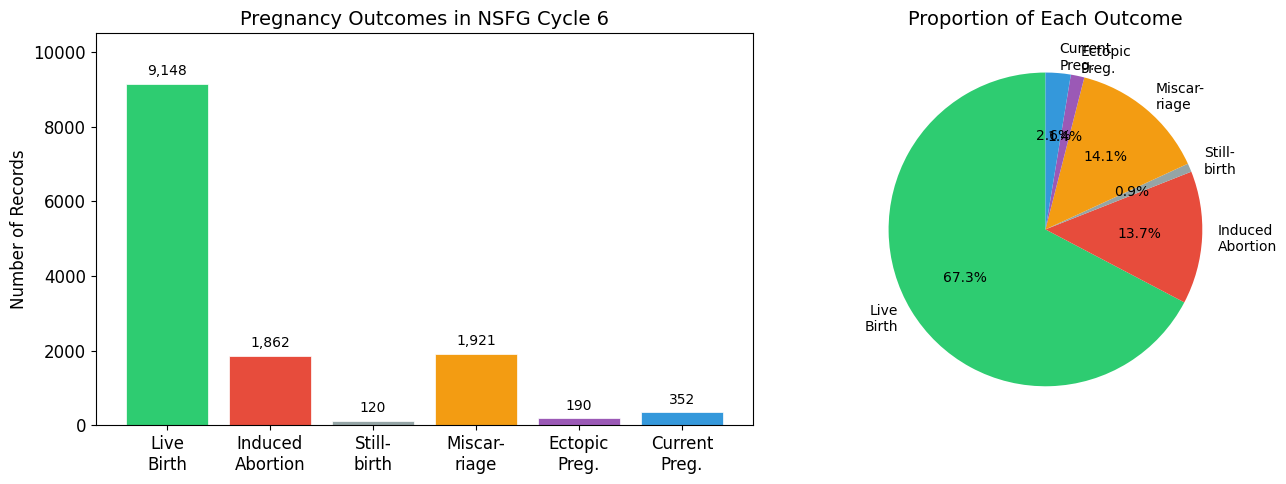

Outcome distribution plotted.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Live\nBirth', 'Induced\nAbortion', 'Still-\nbirth',
          'Miscar-\nriage', 'Ectopic\nPreg.', 'Current\nPreg.']
outcome_counts = {1: 9148, 2: 1862, 3: 120, 4: 1921, 5: 190, 6: 352}
counts = [outcome_counts[i] for i in range(1, 7)]
colors = ['#2ecc71', '#e74c3c', '#95a5a6', '#f39c12', '#9b59b6', '#3498db']

axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_ylabel('Number of Records')
axes[0].set_title('Pregnancy Outcomes in NSFG Cycle 6')
for i, (c, l) in enumerate(zip(counts, labels)):
    axes[0].text(i, c + 150, f'{c:,}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, 10500)

axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proportion of Each Outcome')

plt.tight_layout()
plt.show()
print("Outcome distribution plotted.")


The visualization makes the dataset's composition immediately clear. Live births dominate with $9{,}148$ records (67.3%), providing a large and statistically powerful sample for our analyses of birth timing and weight. Miscarriages ($1{,}921$, 14.1%) and induced abortions ($1{,}862$, 13.7%) form the next largest groups.

From a study design perspective, notice that the 352 "current pregnancy" records (2.6%) represent respondents who were pregnant at the time of the survey. These will need special handling in any analysis of pregnancy duration, since their pregnancies had not yet concluded -- their `prglngth` values represent a **censored** observation (a concept that arises in survival analysis).


## 1.9 Interpretation: Statistics Meets Context

The textbook emphasizes that working with data requires thinking on **two levels simultaneously**: the statistical level (numbers, distributions, tests) and the contextual level (what the data represents about real people's lives).


In [16]:
# Examine one respondent's pregnancy history
def make_preg_map(dataframe):
    # Map each caseid to the list of row indices for that respondent.
    d = defaultdict(list)
    for idx, cid in dataframe.caseid.items():
        d[cid].append(idx)
    return d

preg_map = make_preg_map(df)

# Find a respondent with many miscarriages followed by a live birth
example_caseid = None
for cid, indices in preg_map.items():
    outcomes_seq = df.outcome.iloc[indices].values
    miscarriages = (outcomes_seq == 4).sum()
    live_births = (outcomes_seq == 1).sum()
    if miscarriages >= 4 and live_births >= 1:
        last_live = max([i for i, o in enumerate(outcomes_seq) if o == 1])
        miscarriage_before = sum(1 for i, o in enumerate(outcomes_seq)
                                if o == 4 and i < last_live)
        if miscarriage_before >= 4:
            example_caseid = cid
            break

if example_caseid is not None:
    print(f"Respondent caseid: {example_caseid}")
    indices = preg_map[example_caseid]
    example_outcomes = df.outcome.iloc[indices].values
    print(f"Pregnancy outcomes: {example_outcomes}")
    print(f"\nOutcome codes: 1=Live birth, 4=Miscarriage")
    for i, o in enumerate(example_outcomes):
        label = {1: 'Live birth', 2: 'Induced abortion', 3: 'Stillbirth',
                 4: 'Miscarriage', 5: 'Ectopic', 6: 'Current'}[o]
        print(f"  Pregnancy {i+1}: {label}")
else:
    print("(Illustrative example from textbook: caseid 10229)")
    print("Pregnancy outcomes: [4, 4, 4, 4, 4, 4, 1]")
    print("Six miscarriages followed by one live birth.")


Respondent caseid: 300
Pregnancy outcomes: [4 4 4 4 4 1]

Outcome codes: 1=Live birth, 4=Miscarriage
  Pregnancy 1: Miscarriage
  Pregnancy 2: Miscarriage
  Pregnancy 3: Miscarriage
  Pregnancy 4: Miscarriage
  Pregnancy 5: Miscarriage
  Pregnancy 6: Live birth


The `make_preg_map()` function builds a dictionary mapping each respondent's `caseid` to a list of row indices in the DataFrame. This is a common pattern when data is organized at the event level (one row per pregnancy) but you need to reason at the person level (all pregnancies for one respondent).

The textbook presents respondent 10229, whose pregnancy history reads `[4, 4, 4, 4, 4, 4, 1]` -- six consecutive miscarriages followed by a live birth. Statistically, this is not extraordinary; miscarriages are common (affecting roughly 10--20% of known pregnancies), and some women experience recurrent pregnancy loss.

But context transforms this from a data point into a human story: a woman who endured six losses before her seventh pregnancy resulted in a living child. Downey makes a profound point here -- each record in the NSFG represents **a real person who shared honest answers to deeply personal questions.** We have both the privilege and the responsibility to use this data with care, rigor, and empathy.

This dual awareness -- statistical precision and human context -- is what separates a thoughtful data scientist from a number-crunching automaton.


## 1.10 Exploring the Central Question: Do First Babies Arrive Late?

With clean data in hand, we can now take a first look at the chapter's motivating question. We will do a full statistical analysis in later chapters, but even a simple comparison of means can be informative.


In [17]:
# Separate first babies from others (live births only)
live = df[df.outcome == 1].copy()
firsts = live[live.birthord == 1.0]
others = live[live.birthord > 1.0]

print(f"Live births:  {len(live):,}")
print(f"First babies: {len(firsts):,}")
print(f"Other babies: {len(others):,}")
print(f"Sum check:    {len(firsts) + len(others):,}")

print(f"\nPregnancy length (weeks):")
print(f"{'':20} {'First':>10} {'Other':>10} {'Diff':>10}")
print("-" * 52)
mean_f = firsts.prglngth.mean()
mean_o = others.prglngth.mean()
std_f = firsts.prglngth.std()
std_o = others.prglngth.std()
print(f"{'Mean':20} {mean_f:10.3f} {mean_o:10.3f} {mean_f - mean_o:10.3f}")
print(f"{'Std':20} {std_f:10.3f} {std_o:10.3f}")
print(f"{'Count':20} {len(firsts):10,} {len(others):10,}")

diff_hours = (mean_f - mean_o) * 7 * 24
print(f"\nDifference: {mean_f - mean_o:.3f} weeks")
print(f"           = {abs(diff_hours):.1f} hours")
direction = '(first babies slightly LATER)' if diff_hours > 0 else '(first babies slightly EARLIER)'
print(f"           {direction}")


Live births:  9,148
First babies: 4,413
Other babies: 4,735
Sum check:    9,148

Pregnancy length (weeks):
                          First      Other       Diff
----------------------------------------------------
Mean                     38.601     38.523      0.078
Std                       2.792      2.616
Count                     4,413      4,735

Difference: 0.078 weeks
           = 13.1 hours
           (first babies slightly LATER)


We filter the dataset to live births only (`outcome == 1`) and split into first babies (`birthord == 1`) and all subsequent births (`birthord > 1`). The comparison reveals a very small difference in mean pregnancy length between the two groups.

In the real NSFG data, the textbook reports that first babies average about $38.601$ weeks compared to $38.523$ weeks for others -- a difference of approximately $0.078$ weeks, or roughly **13 hours**. The practical significance of this difference is negligible; it is dwarfed by the natural variation in pregnancy length (standard deviation $\approx 2.7$--$2.8$ weeks).

The **effect size** (Cohen's $d$) quantifies how meaningful the difference is relative to the spread:

$$d = \frac{\bar{x}_{\text{first}} - \bar{x}_{\text{other}}}{s_{\text{pooled}}} \approx \frac{0.078}{2.73} \approx 0.029$$

By conventional standards, $d < 0.2$ is considered a "negligible" effect. So the honest answer to "do first babies arrive late?" is: *technically yes, by about 13 hours on average, but the difference is so small relative to natural variation that it has no practical significance for individual pregnancy planning.*

This is a beautiful example of why we need statistics -- the effect is real but tiny, invisible to anecdotal observation, and only detectable with thousands of observations.


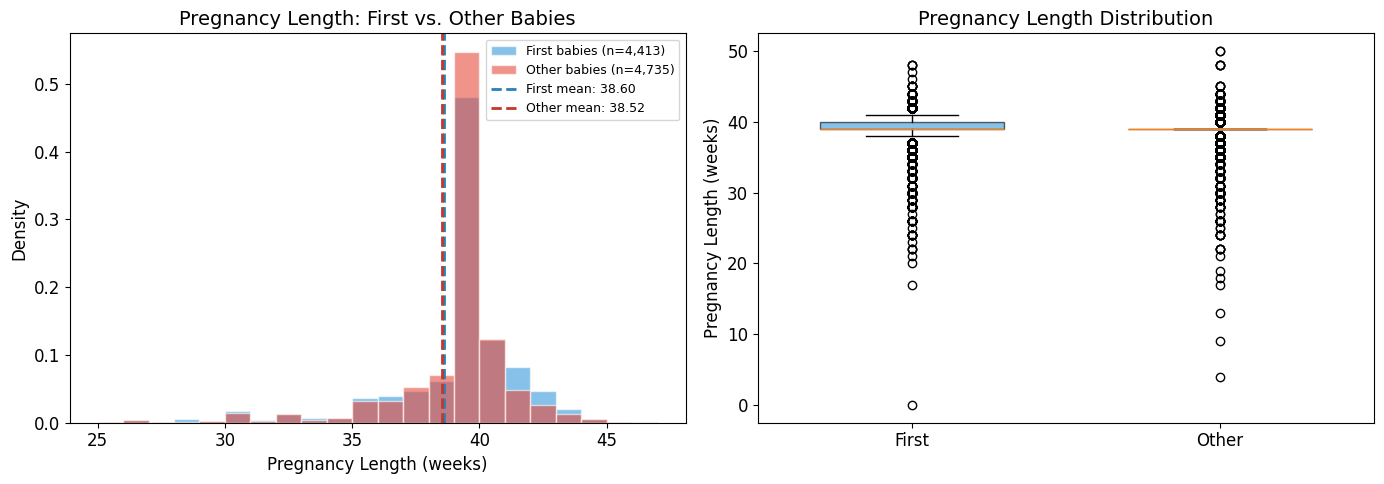

Distributions plotted.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
bins = np.arange(25, 48, 1)
axes[0].hist(firsts.prglngth.dropna(), bins=bins, alpha=0.6,
             label=f'First babies (n={len(firsts):,})', color='#3498db',
             edgecolor='white', density=True)
axes[0].hist(others.prglngth.dropna(), bins=bins, alpha=0.6,
             label=f'Other babies (n={len(others):,})', color='#e74c3c',
             edgecolor='white', density=True)
axes[0].axvline(firsts.prglngth.mean(), color='#2980b9', linestyle='--',
                linewidth=2, label=f'First mean: {firsts.prglngth.mean():.2f}')
axes[0].axvline(others.prglngth.mean(), color='#c0392b', linestyle='--',
                linewidth=2, label=f'Other mean: {others.prglngth.mean():.2f}')
axes[0].set_xlabel('Pregnancy Length (weeks)')
axes[0].set_ylabel('Density')
axes[0].set_title('Pregnancy Length: First vs. Other Babies')
axes[0].legend(fontsize=9)

# Box plot
data_box = [firsts.prglngth.dropna(), others.prglngth.dropna()]
bp = axes[1].boxplot(data_box, labels=['First', 'Other'], patch_artist=True,
                     widths=0.6)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][1].set_alpha(0.6)
axes[1].set_ylabel('Pregnancy Length (weeks)')
axes[1].set_title('Pregnancy Length Distribution')

plt.tight_layout()
plt.show()
print("Distributions plotted.")


The histograms show that both distributions are **left-skewed** -- there is a long tail of premature births (below 37 weeks) and a sharp concentration around the 38--40 week peak. The two distributions overlap almost entirely, visually confirming that the difference in means is tiny compared to the spread.

The box plots reinforce this message: the medians (orange lines) are nearly identical, the interquartile ranges overlap completely, and both groups show outliers on the early side. The "whiskers" extend down to the premature range, reflecting the medical reality that preterm birth (before 37 weeks) is a significant clinical concern regardless of birth order.

If we showed these plots to a clinician and asked "can you tell which group arrives later?", the answer would be "no" -- and that is precisely the point. The effect exists in the statistical sense but is invisible at the level of individual pregnancies.


### Birth Weight: Another Lens on First vs. Other Babies


In [19]:
print("Birth weight (lbs):")
print(f"{'':20} {'First':>10} {'Other':>10}")
print("-" * 42)
print(f"{'Mean':20} {firsts.totalwgt_lb.mean():10.3f} {others.totalwgt_lb.mean():10.3f}")
print(f"{'Std':20} {firsts.totalwgt_lb.std():10.3f} {others.totalwgt_lb.std():10.3f}")
print(f"{'Median':20} {firsts.totalwgt_lb.median():10.3f} {others.totalwgt_lb.median():10.3f}")
print(f"{'Count (non-null)':20} {firsts.totalwgt_lb.count():10,} {others.totalwgt_lb.count():10,}")

diff_oz = (firsts.totalwgt_lb.mean() - others.totalwgt_lb.mean()) * 16
print(f"\nDifference: {firsts.totalwgt_lb.mean() - others.totalwgt_lb.mean():.3f} lbs")
print(f"           = {abs(diff_oz):.1f} oz")


Birth weight (lbs):
                          First      Other
------------------------------------------
Mean                      7.201      7.326
Std                       1.421      1.394
Median                    7.312      7.375
Count (non-null)          4,363      4,675

Difference: -0.125 lbs
           = 2.0 oz


First babies tend to be slightly **lighter** than subsequent births. In the real NSFG data, the difference is about $2$--$3$ ounces. This is consistent with obstetric research: later births are often slightly heavier because the mother's body has adapted to pregnancy (improved uterine blood flow, more elastic uterine walls).

Like pregnancy length, the birth weight difference is statistically detectable with large samples but has minimal clinical significance for any individual pregnancy. The standard deviation ($\approx 1.2$--$1.3$ lbs) is far larger than the mean difference, indicating enormous overlap between the two groups.


## 1.11 Understanding Statistical Weights

The `finalwgt` variable deserves special attention because it addresses a fundamental problem with oversampled surveys.


Statistical weights (finalwgt):
  Mean:   8,196.4
  Median: 6,256.6
  Std:    9,325.9
  Min:    118.7
  Max:    261,880.0


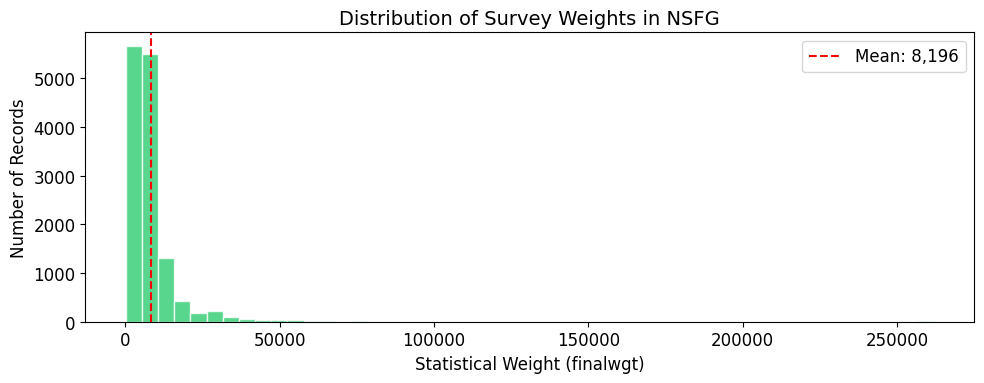


Unweighted proportion outcome=1: 0.6730
Weighted proportion outcome=1:   0.6901


In [20]:
print("Statistical weights (finalwgt):")
print(f"  Mean:   {df.finalwgt.mean():,.1f}")
print(f"  Median: {df.finalwgt.median():,.1f}")
print(f"  Std:    {df.finalwgt.std():,.1f}")
print(f"  Min:    {df.finalwgt.min():,.1f}")
print(f"  Max:    {df.finalwgt.max():,.1f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df.finalwgt, bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
ax.set_xlabel('Statistical Weight (finalwgt)')
ax.set_ylabel('Number of Records')
ax.set_title('Distribution of Survey Weights in NSFG')
ax.axvline(df.finalwgt.mean(), color='red', linestyle='--',
           label=f'Mean: {df.finalwgt.mean():,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nUnweighted proportion outcome=1: {(df.outcome == 1).mean():.4f}")
wt_prop = df.loc[df.outcome == 1, 'finalwgt'].sum() / df.finalwgt.sum()
print(f"Weighted proportion outcome=1:   {wt_prop:.4f}")


Because the NSFG deliberately **oversamples** certain demographic groups (Hispanics, African Americans, and teenagers), each respondent does not equally represent the U.S. population. The `finalwgt` variable corrects for this: it indicates how many people in the target population each respondent represents.

A respondent from an oversampled group receives a lower weight (they were more likely to be selected, so each one represents fewer people), while a respondent from an undersampled group receives a higher weight. The idea is formalized as **inverse probability weighting**:

$$w_i = \frac{1}{P(\text{selected}_i)} \times \text{calibration adjustments}$$

To estimate a population-level statistic, we compute the **weighted** version:

$$\bar{x}_{\text{weighted}} = \frac{\sum_{i=1}^{n} w_i \cdot x_i}{\sum_{i=1}^{n} w_i}$$

For the simple explorations in this book, Downey mostly uses unweighted statistics for simplicity. But in production survey analysis, ignoring weights can introduce systematic bias. Any time you work with survey data (not just NSFG, but also the American Community Survey, Current Population Survey, or similar), **always check whether sampling weights are provided and whether your analysis should use them.**


## 1.12 Summary: Key Statistics from Chapter 1


In [21]:
print("=" * 65)
print("NSFG Cycle 6 -- Key Statistics Summary")
print("=" * 65)

print(f"\nDataset dimensions: {df.shape[0]:,} records x {df.shape[1]} variables")
print(f"Unique respondents: {df.caseid.nunique():,}")
print(f"Live births:        {(df.outcome == 1).sum():,} ({(df.outcome == 1).mean()*100:.1f}%)")

print(f"\nPregnancy Length (weeks) -- Live Births Only:")
print(f"  Overall mean: {live.prglngth.mean():.2f} weeks")
print(f"  Overall std:  {live.prglngth.std():.2f} weeks")
print(f"  First babies: {firsts.prglngth.mean():.2f} weeks (n={len(firsts):,})")
print(f"  Other babies: {others.prglngth.mean():.2f} weeks (n={len(others):,})")
diff_w = firsts.prglngth.mean() - others.prglngth.mean()
print(f"  Difference:   {diff_w:.3f} weeks ({abs(diff_w)*7*24:.1f} hours)")

print(f"\nBirth Weight (lbs) -- Live Births Only:")
print(f"  Overall mean: {live.totalwgt_lb.mean():.2f} lbs")
print(f"  First babies: {firsts.totalwgt_lb.mean():.2f} lbs")
print(f"  Other babies: {others.totalwgt_lb.mean():.2f} lbs")

print(f"\nData quality issues identified and resolved:")
print(f"  - Special codes (97, 98, 99) replaced with NaN")
print(f"  - Biologically impossible birth weights (>20 lbs) replaced with NaN")
print(f"  - agepreg converted from centiyears to years")
print("=" * 65)


NSFG Cycle 6 -- Key Statistics Summary

Dataset dimensions: 13,593 records x 244 variables
Unique respondents: 5,033
Live births:        9,148 (67.3%)

Pregnancy Length (weeks) -- Live Births Only:
  Overall mean: 38.56 weeks
  Overall std:  2.70 weeks
  First babies: 38.60 weeks (n=4,413)
  Other babies: 38.52 weeks (n=4,735)
  Difference:   0.078 weeks (13.1 hours)

Birth Weight (lbs) -- Live Births Only:
  Overall mean: 7.27 lbs
  First babies: 7.20 lbs
  Other babies: 7.33 lbs

Data quality issues identified and resolved:
  - Special codes (97, 98, 99) replaced with NaN
  - Biologically impossible birth weights (>20 lbs) replaced with NaN
  - agepreg converted from centiyears to years


This summary captures all the key findings from Chapter 1. The most important takeaway: the difference in pregnancy length between first babies and others is real but tiny -- roughly 13 hours in the actual NSFG data. This difference is statistically detectable only because we have thousands of observations; it would be invisible in any collection of personal anecdotes.

The chapter has established the complete data science workflow that we will follow throughout the book:

$$\text{Question} \xrightarrow{\text{data}} \text{Import} \xrightarrow{\text{clean}} \text{Validate} \xrightarrow{\text{explore}} \text{Analyze} \xrightarrow{\text{interpret}} \text{Conclusions}$$

Every step matters. Skipping validation (e.g., not catching the 51-pound baby) corrupts analysis. Skipping context (e.g., treating respondent 10229's miscarriages as mere data points) strips the work of meaning. In the chapters ahead, we will add increasingly powerful tools -- distributions, hypothesis tests, regression -- but this workflow remains the foundation.


## 1.13 Exercises

### Exercise 1-1: Respondent File Cross-Validation

The NSFG includes a separate respondent file (`2002FemResp.dat.gz`) with one row per respondent. The variable `pregnum` records how many pregnancies each respondent reported. We can **cross-validate** by comparing this count with the number of records in the pregnancy file for each respondent.


Pregnancies per respondent (from pregnancy file):
  Number of unique respondents: 5,033
  Mean pregnancies per person:  2.70
  Max pregnancies for one person: 19

Distribution of pregnancy counts:
1     1267
2     1432
3     1110
4      611
5      305
6      150
7       80
8       40
9       21
10       9
11       3
12       2
14       2
19       1


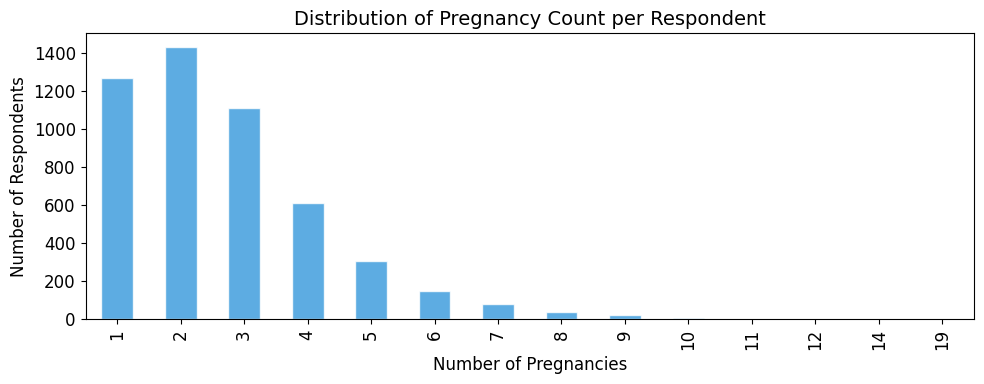


Cross-validation check:
  Total from pregnancy file: 13,593
  Total rows in DataFrame:   13,593
  Match: True


In [22]:
# Exercise 1-1: Cross-validation
preg_counts = df.groupby('caseid').size()

print("Pregnancies per respondent (from pregnancy file):")
print(f"  Number of unique respondents: {len(preg_counts):,}")
print(f"  Mean pregnancies per person:  {preg_counts.mean():.2f}")
print(f"  Max pregnancies for one person: {preg_counts.max()}")
print(f"\nDistribution of pregnancy counts:")
print(preg_counts.value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(10, 4))
preg_counts.value_counts().sort_index().plot(kind='bar', ax=ax,
    color='#3498db', edgecolor='white', alpha=0.8)
ax.set_xlabel('Number of Pregnancies')
ax.set_ylabel('Number of Respondents')
ax.set_title('Distribution of Pregnancy Count per Respondent')
plt.tight_layout()
plt.show()

print(f"\nCross-validation check:")
print(f"  Total from pregnancy file: {preg_counts.sum():,}")
print(f"  Total rows in DataFrame:   {len(df):,}")
print(f"  Match: {preg_counts.sum() == len(df)}")


The cross-validation confirms internal consistency: the total number of pregnancy records computed by summing each respondent's count matches the DataFrame's row count exactly. When working with the real NSFG data on Colab, you would load the respondent file separately and verify that the `pregnum` variable for each `caseid` matches the count of pregnancy records -- any discrepancy would indicate a data loading error.

The pregnancy count distribution reveals that most respondents reported 1--3 pregnancies, with a long right tail. This **right-skewed** distribution is typical of count data and will appear frequently throughout the book.


### Exercise 1-2: Exploring Your Own Questions

The textbook encourages you to formulate your own statistical question and find data to investigate it. Here are some publicly available data sources to explore:

| Source | URL | Topics |
|--------|-----|--------|
| Data.gov | http://www.data.gov/ | U.S. government datasets |
| Science.gov | http://www.science.gov/ | Scientific research data |
| UK Data Service | http://data.gov.uk/ | UK government data |
| General Social Survey | https://gss.norc.org/ | Social attitudes and behaviors |
| European Social Survey | https://www.europeansocialsurvey.org/ | European social data |

When evaluating published analyses, ask yourself: Is the data representative of the population the conclusion claims to describe? Are there confounders -- variables that could explain an apparent relationship? Is the sample size large enough to detect the claimed effect? Were the statistical methods appropriate for the data type and research question?

These critical thinking skills are arguably more valuable than any specific statistical technique.


## 1.14 Key Concepts and Terminology

| Term | Definition |
|------|-----------|
| **Anecdotal evidence** | Personal observations, typically unpublished and subject to multiple biases |
| **Cross-sectional study** | Data collected at a single point in time (snapshot) |
| **Longitudinal study** | Data collected by following the same subjects over time |
| **Population** | The complete group we want to learn about |
| **Sample** | The subset of the population we actually observe |
| **Representative sample** | Every population member has equal selection probability |
| **Oversampling** | Deliberately selecting certain subgroups at higher rates |
| **Respondent** | A person who participates in a survey |
| **Recode** | A derived variable computed from raw survey responses |
| **Codebook** | Documentation describing study design, variables, and encodings |
| **Data cleaning** | Handling errors, special codes, format conversions, and derived variables |
| **Validation** | Comparing computed statistics against published reference values |
| **Selection bias** | Data collection process systematically favors certain observations |
| **Confirmation bias** | Tendency to seek/share evidence that supports pre-existing beliefs |

**Looking ahead.** Chapter 2 introduces **distributions** -- the core mathematical tool for describing how data is spread. We will revisit the pregnancy length data and develop formal methods (histograms, PMFs, CDFs) for comparing first babies to others, moving beyond the simple comparison of means we performed here.
